**Assignment - Credit card defaults**

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

Import the dataset into a pandas dataframe. The first row consists of names that are
slightly more descriptive than just 'X1'. If you want, you can rename the column names
using the first row, then drop the first row. You can use df.rename() and
df.drop(df.index[0], axis=0)  
The dataset contains a column named Unnamed: 0, which is just an index. You can throw
this column away using df.drop.

The code given on the webpage is loading the data from the web.
  
Below is code to read data from xls (extracted from zip from web)

In [1]:
import pandas as pd

df = pd.read_excel('data/default of credit card clients.xls', header=1)
# PAY_x is not consistent with PAY_AMTx
# target has long name
df.rename(columns={'PAY_0': 'PAY_1',
                   'default payment next month': 'IS_DEFAULT'
                   }, inplace=True)
# drop the first column (ID)
df.drop(columns=['ID'], inplace=True)

# split it in X and y
X = df.drop(columns=['IS_DEFAULT'])
y = df['IS_DEFAULT']

Split the dataset into a train-, and test set, using  
`train_test_split(X, y, test_size=0.5, random_state=42)`

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(15000, 23) (15000,) (15000, 23) (15000,)


 Write a preprocessor that  
• applies a one-hot encoding to process the categorical variables.  
• rescales the features that are not categorical using a standard scale

First, check which columns have limited unique values, these are likely
to be categorical

In [3]:
print(X.nunique())

categorical_cols = [col for col in X.columns if X[col].nunique() < 10]
print(categorical_cols)

LIMIT_BAL       81
SEX              2
EDUCATION        7
MARRIAGE         4
AGE             56
PAY_1           11
PAY_2           11
PAY_3           11
PAY_4           11
PAY_5           10
PAY_6           10
BILL_AMT1    22723
BILL_AMT2    22346
BILL_AMT3    22026
BILL_AMT4    21548
BILL_AMT5    21010
BILL_AMT6    20604
PAY_AMT1      7943
PAY_AMT2      7899
PAY_AMT3      7518
PAY_AMT4      6937
PAY_AMT5      6897
PAY_AMT6      6939
dtype: int64
['SEX', 'EDUCATION', 'MARRIAGE']


So, from SEX, EDUCATION and MARRIAGE the one-hot encoding can be done, all other standard scaler

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

categorical_cols = [col for col in X.columns if X[col].nunique() < 10]
other_cols = [col for col in X.columns if X[col].nunique() >= 10]

cat_pipeline = make_pipeline(
  # OneHotEncoder(handle_unknown='ignore'),
  OneHotEncoder(handle_unknown='warn'),
)
standard_pipeline = make_pipeline(
  StandardScaler(),
)

preprocessor = ColumnTransformer([
  ("cat", cat_pipeline, categorical_cols),
  ("num", standard_pipeline, other_cols),
  # ("", "passthrough", other_cols),
])

X_prep = preprocessor.fit_transform(X_train)

print(preprocessor.get_feature_names_out())
print(X_prep.shape)


['cat__SEX_1' 'cat__SEX_2' 'cat__EDUCATION_0' 'cat__EDUCATION_1'
 'cat__EDUCATION_2' 'cat__EDUCATION_3' 'cat__EDUCATION_4'
 'cat__EDUCATION_5' 'cat__EDUCATION_6' 'cat__MARRIAGE_0' 'cat__MARRIAGE_1'
 'cat__MARRIAGE_2' 'cat__MARRIAGE_3' 'num__LIMIT_BAL' 'num__AGE'
 'num__PAY_1' 'num__PAY_2' 'num__PAY_3' 'num__PAY_4' 'num__PAY_5'
 'num__PAY_6' 'num__BILL_AMT1' 'num__BILL_AMT2' 'num__BILL_AMT3'
 'num__BILL_AMT4' 'num__BILL_AMT5' 'num__BILL_AMT6' 'num__PAY_AMT1'
 'num__PAY_AMT2' 'num__PAY_AMT3' 'num__PAY_AMT4' 'num__PAY_AMT5'
 'num__PAY_AMT6']
(15000, 33)


**Comparing models on recall and precision**  
We will now compare the performance of two KNN classifiers (sklearn.neighbors.KNeighborsClassifier).  
One with n_neighbors = 5 and one with n_neighbors = 100.  

Make a pipeline that combines the preprocessor with the KNN classifiers.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

def create_pipeline_KKN(preproc, num_neigh):
    ret_pipeline = Pipeline(steps=[
        ('preprocessor', preproc),
        ('classifier', KNeighborsClassifier(n_neighbors=num_neigh))
    ])
    return ret_pipeline

pipeline_kknV = create_pipeline_KKN(preprocessor, 5)
pipeline_kknC = create_pipeline_KKN(preprocessor, 100)

Fit the two KNN classifiers on the training set

In [6]:
pipeline_kknV.fit(X_train, y_train)
pipeline_kknC.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Use your fitted models to make predictions on the test set

In [7]:
predictsV = pipeline_kknV.predict(X_test)
predictsC = pipeline_kknC.predict(X_test)

Compute the accuracy of the models on the test set.  
Compare with the accuracy that you would get if you would classify everything as class 0.

In [8]:
from sklearn.metrics import accuracy_score
import numpy as np

accuracyV = accuracy_score(y_test, predictsV)
accuracyC = accuracy_score(y_test, predictsC)
predictAllZero = np.zeros(len(predictsV), dtype=predictsV.dtype)
accuracy0 = accuracy_score(y_test, predictAllZero)

print(f"Model Accuracy (KKN 5)  : {accuracyV:.2}")
print(f"Model Accuracy (KKN 100): {accuracyC:.2}")
print(f"Model Accuracy (all 0)  : {accuracy0:.2}")

Model Accuracy (KKN 5)  : 0.79
Model Accuracy (KKN 100): 0.81
Model Accuracy (all 0)  : 0.78


Also compare with the results in table 1 in the paper. What is your opinion?

In [9]:
errorRateV = 1 - accuracyV
errorRateC = 1 - accuracyC
errorRate0 = 1 - accuracy0

print(f"Error Rate (KKN 5)  : {errorRateV:.2}")
print(f"Error Rate (KKN 100): {errorRateC:.2}")
print(f"Error Rate (all 0)  : {errorRate0:.2}")

Error Rate (KKN 5)  : 0.21
Error Rate (KKN 100): 0.19
Error Rate (all 0)  : 0.22


Error rates are not bad compared with table 1 in the paper.

Compute recall and precision of the models on the test set

In [10]:
from sklearn.metrics import recall_score, precision_score

recallV = recall_score(y_test, predictsV)
recallC = recall_score(y_test, predictsC)

precisionV = precision_score(y_test, predictsV)
precisionC = precision_score(y_test, predictsV)

print(f"KKN 5  : recall {recallV:.2%} precision {precisionV:.2%}")
print(f"KKN 100: recall {recallC:.2%} precision {precisionC:.2%}")

KKN 5  : recall 35.51% precision 54.42%
KKN 100: recall 27.69% precision 54.42%


Suppose recall is the metric of interest in your project, and suppose he choice is between a KNN classifier
with 5 neighbours and one with 100 neighbors. What would be your advice?  

Recall is higher on KKN 5, but still pretty low

Find the probability of default that your model assigns to each instance in the test set

In [11]:
from sklearn.model_selection import cross_val_predict

probV = cross_val_predict(pipeline_kknV, X_test, y_test, cv=5, method='predict_proba')
probC = cross_val_predict(pipeline_kknC, X_test, y_test, cv=5, method='predict_proba')

Create a single plot with precision-recall curves of both KNN models (based on the probabilities of
default that you found)

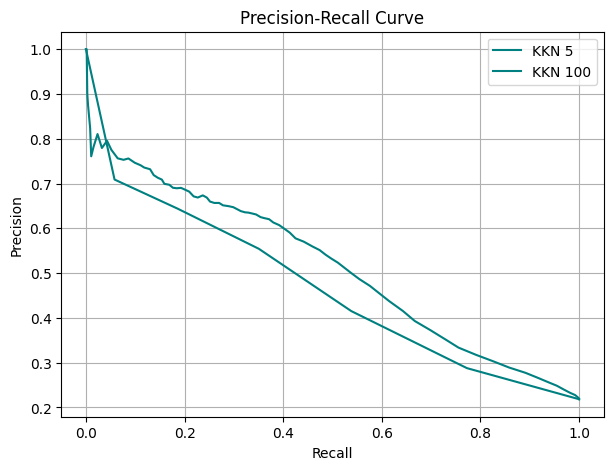

In [12]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

curve_precisionV, curve_recallV, curve_thresholdsV = precision_recall_curve(y_test, probV[:,1])
curve_precisionC, curve_recallC, curve_thresholdsC = precision_recall_curve(y_test, probC[:,1])

plt.figure(figsize=(7, 5))
plt.plot(curve_recallV, curve_precisionV, color='teal', label='KKN 5')
plt.plot(curve_recallC, curve_precisionC, color='teal', label='KKN 100')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()